# Experimento 4 — Última oración con opinión + LinearSVC

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento2.ipynb` (el mejor modelo para la competencia) e intenta mejorarlo. La sección 1
repite de forma resumida la configuración común (misma semilla, mismo split y mismos folds). Los experimentos
anteriores **no se vuelven a ejecutar**: sus métricas se registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 4 — Última oración con opinión + LinearSVC

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de los experimentos 2 y 3 tomadas de sus notebooks (no se vuelven a ejecutar aquí)
resultados.append({
    "experimento": 2,
    "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
    "mejores_params": {"clf__C": 10}, "acc_train": 0.9999, "acc_cv": 0.8865, "std_cv": 0.0099,
    "f1_cv": 0.8908, "acc_test": 0.8992, "f1_test": 0.9031, "envio": "submission_02.csv", "kaggle_publico": 0.88,
})
resultados.append({
    "experimento": 3,
    "descripcion": "TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",
    "mejores_params": {"clf__C": 10}, "acc_train": 0.9980, "acc_cv": 0.7978, "std_cv": 0.0146,
    "f1_cv": 0.8064, "acc_test": 0.7963, "f1_test": 0.8054, "envio": "submission_03.csv", "kaggle_publico": None,
})

# Accuracy por fold del experimento 2 (mismos folds; experimento3.ipynb, sección 2.3) para comparar fold por fold
ACC_FOLDS_E2 = np.array([0.8938, 0.8734, 0.8984, 0.8906, 0.8760])

# Prueba de robustez sobre el test (experimento2.ipynb, sección 2.9; experimento3.ipynb, sección 2.6)
ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 2 (final de la reseña)", "escenario": "Original", "accuracy": 0.8992},
    {"modelo": "Exp. 2 (final de la reseña)", "escenario": "Oraciones desordenadas", "accuracy": 0.6858},
    {"modelo": "Exp. 2 (final de la reseña)", "escenario": "Última oración al inicio", "accuracy": 0.5742},
    {"modelo": "Exp. 3 (veredicto por contenido)", "escenario": "Original", "accuracy": 0.7962},
    {"modelo": "Exp. 3 (veredicto por contenido)", "escenario": "Oraciones desordenadas", "accuracy": 0.8004},
    {"modelo": "Exp. 3 (veredicto por contenido)", "escenario": "Última oración al inicio", "accuracy": 0.7996},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN


## 2. Experimento 4 — Última oración con opinión + LinearSVC

**Motivación:** el experimento 2 obtuvo 0,887 en CV, 0,899 en test y **0,88 en el leaderboard público** de Kaggle,
mientras que otros equipos llegan a 0,90. Su idea (la última oración concentra el veredicto) funciona, pero todavía
falla en el 16 % de las reseñas `negativo`/`positivo`.

**Hipótesis:** muchos de esos errores ocurren porque la última oración **no contiene el veredicto**: es una frase
evasiva (*"ni lo mejor ni lo peor"*) o descriptiva (*"lo tengo en la sala"*). Si el modelo usa la **última oración
con opinión** en lugar de la última oración, debería acertar más.

**Proceso:**
1. Analizar los errores del experimento 2 (sobre train, con `cross_val_predict`).
2. Comprobar si las reseñas que terminan en una evasiva se pueden predecir.
3. Construir un detector de oraciones con opinión, entrenado dentro del pipeline, para saltar las oraciones finales
   sin opinión.
4. Comparar candidatos con CV (incluido el cambio de clasificador a LinearSVC) y verificar la mejora fold por fold.
5. Ajustar el hiperparámetro del modelo final, evaluar en test (incluida la prueba de robustez) y enviar.

### 2.1 ¿Dónde se equivoca el experimento 2?

Se reconstruye la configuración del experimento 2 (texto completo + última oración + tras el último conector, LR con
`C = 10`) solo para obtener sus predicciones de CV sobre `X_train` con `cross_val_predict`. El test no se usa.

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)


def dividir_oraciones(texto):
    """Lista de oraciones de un texto normalizado."""
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def partes_e2(textos):
    return pd.DataFrame({
        "texto": list(textos),
        "ultima": [dividir_oraciones(t)[-1] for t in textos],
        "tras_conector": [tras_ultimo_conector(t) for t in textos],
    })


def tfidf_palabras():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)


pipe_e2 = Pipeline([
    ("partes", FunctionTransformer(partes_e2)),
    ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in ["texto", "ultima", "tras_conector"]])),
    ("clf", LogisticRegression(C=10, max_iter=3000, random_state=SEED)),
])
pred_cv_e2 = cross_val_predict(pipe_e2, X_train, y_train, cv=skf, n_jobs=-1)

mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
errores_e2 = (pred_cv_e2 != y_np) & mascara_np
ultimas = X_train.map(lambda t: dividir_oraciones(t)[-1]).to_numpy()
print(f"Accuracy CV (exp. 2): {(pred_cv_e2 == y_np).mean():.4f}")
print(f"Errores negativo/positivo: {errores_e2.sum()} de {mascara_np.sum()}")

Accuracy CV (exp. 2): 0.8865
Errores negativo/positivo: 1077 de 6739


In [7]:
def inicio(oracion, n=3):
    return " ".join(re.sub(r"[,.;]", "", oracion).split()[:n])


c_err = Counter(inicio(s) for s in ultimas[errores_e2])
c_tot = Counter(inicio(s) for s in ultimas[mascara_np])
tabla_inicios = pd.DataFrame(
    [{"inicio de la última oración": k, "errores": v, "total": c_tot[k], "tasa de error": v / c_tot[k]}
     for k, v in c_err.most_common(20)]
).round(2)
tabla_inicios

,inicio de la última oración,errores,total,tasa de error
0,cada quien que,50,103,0.49
1,todavia no me,44,79,0.56
2,ni lo mejor,42,77,0.55
3,ni tan bueno,40,81,0.49
4,sigo con dudas,37,76,0.49
5,hay de todo,36,68,0.53
6,para gustos colores,36,76,0.47
7,en fin ni,33,64,0.52
8,por otro lado,32,118,0.27
9,no sabria bien,29,58,0.50


In [8]:
largo = np.array([len(s.split()) for s in ultimas])
filas = []
for lo, hi in [(0, 6), (6, 9), (9, 12), (12, 16), (16, 200)]:
    m = mascara_np & (largo >= lo) & (largo < hi)
    filas.append({"palabras en la última oración": f"{lo}–{hi - 1}" if hi < 200 else f"{lo}+",
                  "reseñas negativo/positivo": m.sum(), "tasa de error": (pred_cv_e2[m] != y_np[m]).mean()})
pd.DataFrame(filas).round(3)

,palabras en la última oración,reseñas negativo/positivo,tasa de error
0,0–5,574,0.458
1,6–8,1091,0.254
2,9–11,2124,0.106
3,12–15,1516,0.110
4,16+,1434,0.100


**Lectura**

- Los inicios con más errores son **frases evasivas** al final de la reseña: *"cada quien que..."*, *"todavía no me
  decido"*, *"ni lo mejor ni lo peor"*, *"ni tan bueno ni tan malo"*, *"sigo con dudas"*, *"hay de todo"*, *"para
  gustos, colores"*... Su tasa de error ronda el **50 %**, como lanzar una moneda.
- También fallan las últimas oraciones **descriptivas** (*"lo tengo..."*, *"lo dejé..."*, *"la uso..."*): no traen
  opinión y el veredicto está en una oración anterior.
- Las últimas oraciones cortas (menos de 6 palabras, casi siempre evasivas) tienen un error del 46 %, frente a ≈ 10 %
  cuando la última oración tiene 9 palabras o más.
- En cambio, las últimas oraciones con conector conclusivo (*"aun así"*, *"al final"*, *"a fin de cuentas"*) casi
  nunca fallan.

### 2.2 ¿Se pueden predecir las reseñas que terminan en una evasiva?

Se define una lista de frases evasivas (a partir de la tabla anterior) y, **solo con las reseñas
`negativo`/`positivo` de `X_train` que terminan en una evasiva**, se entrena un clasificador con distintas partes
de la reseña. Si alguna parte predice la etiqueta por encima del azar (50 %), la información existe y se puede
aprovechar.

In [9]:
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()
print(f"Reseñas negativo/positivo que terminan en evasiva: {termina_evasiva[mascara_np].mean():.1%} "
      f"(n = {(termina_evasiva & mascara_np).sum()})")
print(f"Reseñas neutral que terminan en evasiva: {termina_evasiva[~mascara_np].mean():.1%}")

m_ev = termina_evasiva & mascara_np
X_ev, y_ev = X_train[m_ev], y_train[m_ev]
VARIANTES = {
    "texto completo": lambda t: t,
    "texto sin la evasiva": lambda t: " ".join(sin_evasivas(t)),
    "primera oración": lambda t: sin_evasivas(t)[0],
    "última oración antes de la evasiva": lambda t: sin_evasivas(t)[-1],
    "penúltima oración antes de la evasiva": lambda t: sin_evasivas(t)[-2] if len(sin_evasivas(t)) > 1 else "",
    "solo la evasiva": lambda t: " ".join(o for o in dividir_oraciones(t) if es_evasiva(o)),
}
filas = []
for nombre, extraer in VARIANTES.items():
    p = Pipeline([("tfidf", tfidf_palabras()), ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED))])
    s = cross_val_score(p, X_ev.map(extraer), y_ev, cv=skf, n_jobs=-1)
    filas.append({"parte usada": nombre, "accuracy CV": s.mean(), "std": s.std()})
pd.DataFrame(filas).round(3)

Reseñas negativo/positivo que terminan en evasiva: 16.0% (n = 1078)
Reseñas neutral que terminan en evasiva: 0.3%


,parte usada,accuracy CV,std
0,texto completo,0.515,0.029
1,texto sin la evasiva,0.518,0.028
2,primera oración,0.517,0.025
3,última oración antes de la evasiva,0.515,0.034
4,penúltima oración antes de la evasiva,0.538,0.042
5,solo la evasiva,0.509,0.019


**Lectura**

- Ninguna parte de la reseña predice la etiqueta por encima del azar (todas ≈ 0,46–0,52). En estas reseñas la
  estructura es la misma (opinión A, opinión B de signo contrario, evasiva) y la etiqueta parece **asignada al azar**:
  no depende ni de la primera ni de la última opinión.
- Esto equivale a **ruido irreducible**: alrededor del 16 % de las reseñas `negativo`/`positivo` (≈ 11 % de todas)
  tienen una etiqueta que ningún modelo puede predecir mejor que una moneda. Eso fija un techo aproximado de accuracy
  de ≈ 0,94 (≈ 5,5 puntos de error inevitable) para cualquier modelo de este conjunto de datos.
- Conclusión: no vale la pena intentar resolver esas reseñas. Lo que sí se puede hacer es **evitar que la evasiva y
  las oraciones descriptivas confundan al modelo en el resto de las reseñas**.

### 2.3 Detector de oraciones con opinión

Para saltar no solo las evasivas sino también las oraciones finales **descriptivas**, se entrena un pequeño
clasificador de oraciones "con opinión" frente a "sin opinión":

| Ejemplos | Origen |
|---|---|
| **sin opinión** | todas las oraciones de reseñas `neutral` (son descriptivas, sección 1.4 de `experimento1.ipynb`) |
| **con opinión** | oraciones de reseñas `negativo`/`positivo` que empiezan con un conector conclusivo o concesivo (casi siempre expresan una opinión, `experimento3.ipynb`) |

Con él se define la **última oración con opinión**: recorriendo la reseña desde el final, la primera oración que no
es evasiva y que el detector considera con opinión (probabilidad ≥ 0,5). Si ninguna cumple, se usa la última oración
no evasiva.

**¿Es leakage?** El detector usa las etiquetas para construir sus ejemplos, así que **debe entrenarse solo con los
datos de entrenamiento de cada fold**. Por eso se implementa como un transformador de scikit-learn
(`PartesConOpinion`) cuyo `fit` entrena el detector: dentro del `Pipeline`, en cada fold solo ve las reseñas de
entrenamiento de ese fold, y al predecir solo usa el texto. Al generar el envío se entrena con train completo; nunca
con eval.

In [10]:
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"


class PartesConOpinion(BaseEstimator, TransformerMixin):
    """Separa cada reseña en partes para vectorizarlas por separado.

    - texto: reseña completa
    - ultima_op: última oración con opinión (ni evasiva ni descriptiva), según un detector entrenado en fit()
    - tras_sin_ev: fragmento desde el último conector, ignorando las oraciones evasivas
    """

    def __init__(self, usar_detector=True, umbral=0.5):
        self.usar_detector = usar_detector
        self.umbral = umbral

    def fit(self, X, y):
        if self.usar_detector:
            con_opinion, sin_opinion = [], []
            for texto, etiqueta in zip(X, y):
                for oracion in dividir_oraciones(texto):
                    if etiqueta == "neutral":
                        sin_opinion.append(oracion)
                    elif (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                        con_opinion.append(oracion)
            self.detector_ = Pipeline([
                ("tfidf", tfidf_palabras()),
                ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
            ]).fit(con_opinion + sin_opinion, [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def _ultima_con_opinion(self, texto):
        candidatas = sin_evasivas(texto)
        if not self.usar_detector:
            return candidatas[-1]
        prob = self.detector_.predict_proba(candidatas)[:, 1]
        for oracion, p in zip(reversed(candidatas), reversed(prob)):
            if p >= self.umbral:
                return oracion
        return candidatas[-1]

    def transform(self, X):
        return pd.DataFrame({
            "texto": list(X),
            "ultima_op": [self._ultima_con_opinion(t) for t in X],
            "tras_sin_ev": [tras_ultimo_conector(" ".join(sin_evasivas(t))) for t in X],
        })


# Ejemplos ilustrativos: reseñas negativo/positivo de train donde la última oración con opinión
# NO es la última oración (el detector salta una oración final evasiva o descriptiva)
ejemplo = PartesConOpinion().fit(X_train, y_train)
partes_ej = ejemplo.transform(X_train[mascara_np])
distinta = partes_ej["ultima_op"].to_numpy() != X_train[mascara_np].map(lambda t: dividir_oraciones(t)[-1]).to_numpy()
print(f"Reseñas negativo/positivo donde la última oración con opinión no es la última: {distinta.mean():.1%}\n")
muestra = X_train[mascara_np][distinta & ~termina_evasiva[mascara_np]].head(3)
for texto, op in zip(muestra, ejemplo.transform(muestra)["ultima_op"]):
    print("ÚLTIMA ORACIÓN     :", dividir_oraciones(texto)[-1])
    print("ÚLTIMA CON OPINIÓN :", op, "\n")

Reseñas negativo/positivo donde la última oración con opinión no es la última: 24.0%

ÚLTIMA ORACIÓN     : lo uso casi todos los dias en la oficina.
ÚLTIMA CON OPINIÓN : de paso, la relacion calidad-precio resulto fiable en general. 

ÚLTIMA ORACIÓN     : comento rapido: la velocidad cumple con creces.
ÚLTIMA CON OPINIÓN : la verdad lo he estado usando casi a diario para el trabajo. 

ÚLTIMA ORACIÓN     : un amigo me dijo que quiza era el firmware, no lo he revisado.
ÚLTIMA CON OPINIÓN : eso si, con la conexion no pare de tener problemas desde el primer dia, y eso que el router esta cerca. 



### 2.4 Comparación de candidatos

Todos con los mismos 5 folds. Se compara la configuración del experimento 2 con versiones que usan la última oración
con opinión, con y sin el detector, y con dos clasificadores: regresión logística y **LinearSVC** (SVM lineal), que
en el plan original estaba previsto para la matriz de modelos. También se prueban n-gramas de caracteres en la
última oración con opinión, por los errores de tipeo.

In [11]:
def pipeline_e4(clf, usar_detector=True, caracteres=False):
    transformadores = [(c, tfidf_palabras(), c) for c in ["texto", "ultima_op", "tras_sin_ev"]]
    if caracteres:
        transformadores.append(("ultima_op_char",
                                TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True),
                                "ultima_op"))
    return Pipeline([
        ("partes", PartesConOpinion(usar_detector=usar_detector)),
        ("tfidf", ColumnTransformer(transformadores)),
        ("clf", clf),
    ])


def LR():
    return LogisticRegression(C=10, max_iter=4000, random_state=SEED)


def SVC(C=0.5):
    return LinearSVC(C=C, max_iter=5000, random_state=SEED)


CANDIDATOS = {
    "sin evasivas (sin detector), LR": pipeline_e4(LR(), usar_detector=False),
    "con detector, LR": pipeline_e4(LR()),
    "con detector, LinearSVC C=0,5": pipeline_e4(SVC(0.5)),
    "con detector, LinearSVC C=0,2": pipeline_e4(SVC(0.2)),
    "con detector + caracteres, LinearSVC C=0,5": pipeline_e4(SVC(0.5), caracteres=True),
}

acc_folds = {"[ref. exp. 2] texto + última + tras conector, LR": ACC_FOLDS_E2}
for nombre, pipe in CANDIDATOS.items():
    acc_folds[nombre] = cross_val_score(pipe, X_train, y_train, cv=skf, n_jobs=-1)

comparacion = pd.DataFrame({
    "acc_cv": {k: v.mean() for k, v in acc_folds.items()},
    "std": {k: v.std() for k, v in acc_folds.items()},
    "folds que gana al exp. 2": {k: int((v > ACC_FOLDS_E2).sum()) for k, v in acc_folds.items()},
}).round(4).sort_values("acc_cv", ascending=False)
comparacion

,acc_cv,std,folds que gana al exp. 2
"con detector, LinearSVC C=0,2",0.9009,0.0057,5
"con detector, LinearSVC C=0,5",0.8993,0.0072,5
"con detector + caracteres, LinearSVC C=0,5",0.8983,0.0060,5
"con detector, LR",0.8964,0.0080,4
"sin evasivas (sin detector), LR",0.8878,0.0077,2
"[ref. exp. 2] texto + última + tras conector, LR",0.8864,0.0099,0


In [12]:
pd.DataFrame({k: v for k, v in acc_folds.items()},
             index=[f"fold {i}" for i in range(1, 6)]).T.round(4)

,fold 1,fold 2,fold 3,fold 4,fold 5
"[ref. exp. 2] texto + última + tras conector, LR",0.8938,0.8734,0.8984,0.8906,0.8760
"sin evasivas (sin detector), LR",0.8938,0.8818,0.8938,0.8943,0.8755
"con detector, LR",0.9052,0.8932,0.8974,0.9031,0.8828
"con detector, LinearSVC C=0,5",0.9062,0.8964,0.9005,0.9062,0.8870
"con detector, LinearSVC C=0,2",0.9021,0.9010,0.9052,0.9062,0.8901
"con detector + caracteres, LinearSVC C=0,5",0.9078,0.8943,0.8984,0.9010,0.8901


**Lectura de la comparación**

- **Solo saltar las evasivas no basta** (0,8878, gana en 2 de 5 folds): las reseñas que terminan en evasiva siguen
  siendo impredecibles (sección 2.2) y las oraciones finales descriptivas siguen confundiendo al modelo.
- **El detector de opinión es lo que aporta:** con regresión logística sube a 0,8964 y gana en 4 de 5 folds.
- **LinearSVC con `C = 0,2`** llega a **0,9009 ± 0,0057** y gana en los **5 folds**. Pero en esta tabla la regresión
  logística solo se probó con `C = 10`; la elección justa entre ambos clasificadores, cada uno con su propia grilla
  de `C`, se hace en la sección 2.5.
- **Los n-gramas de caracteres no aportan** (0,8983): la normalización y el `min_df` ya absorben buena parte de los
  errores de tipeo en las palabras que deciden el veredicto.

### 2.5 Modelo del experimento 4

Pipeline: `PartesConOpinion` (con detector) → TF-IDF (1,2) del texto completo, de la última oración con opinión y
del fragmento tras el último conector (sin evasivas) → clasificador.

En la comparación anterior, la regresión logística se evaluó con un solo valor de `C` (10, el óptimo de los
experimentos 1 y 2), mientras que LinearSVC se evaluó con varios. Para que la elección del clasificador sea justa,
aquí **el clasificador también es un hiperparámetro**: `GridSearchCV` prueba regresión logística y LinearSVC, **cada
uno con su propia grilla de `C`**, sobre los mismos folds, y elige el mejor par (clasificador, `C`). En ambos, un `C`
menor significa más regularización.

In [13]:
grid_e4 = [
    {"clf": [LogisticRegression(max_iter=4000, random_state=SEED)], "clf__C": [1, 3, 10, 30]},
    {"clf": [LinearSVC(max_iter=5000, random_state=SEED)], "clf__C": [0.05, 0.1, 0.2, 0.5, 1]},
]
busqueda_e4 = GridSearchCV(
    pipeline_e4(SVC()), grid_e4, cv=skf, scoring=SCORING, refit="accuracy",
    return_train_score=True, n_jobs=-1,
)
busqueda_e4.fit(X_train, y_train)

mejor = busqueda_e4.best_params_
print("Mejor clasificador:", type(mejor["clf"]).__name__, "| C =", mejor["clf__C"])
print(f"Accuracy CV: {busqueda_e4.best_score_:.4f}")

tabla_e4 = tabla_cv(busqueda_e4)
params = tabla_e4.pop("params")
tabla_e4.insert(0, "C", params.map(lambda p: p["clf__C"]))
tabla_e4.insert(0, "clasificador", params.map(lambda p: type(p["clf"]).__name__))
tabla_e4.sort_values(["clasificador", "C"])

Mejor clasificador: LinearSVC | C = 0.2
Accuracy CV: 0.9009


,clasificador,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste
4,LinearSVC,0.05,0.9408,0.8911,0.0081,0.8958,23.1914
5,LinearSVC,0.10,0.9595,0.8976,0.0065,0.9021,22.6979
6,LinearSVC,0.20,0.9770,0.9009,0.0057,0.9055,19.2801
7,LinearSVC,0.50,0.9960,0.8993,0.0072,0.9040,16.7454
8,LinearSVC,1.00,0.9996,0.8970,0.0079,0.9018,16.6988
0,LogisticRegression,1.00,0.9770,0.8973,0.0069,0.9020,26.3314
1,LogisticRegression,3.00,0.9969,0.8971,0.0082,0.9019,26.5673
2,LogisticRegression,10.00,1.0000,0.8964,0.0080,0.9012,27.2143
3,LogisticRegression,30.00,1.0000,0.8945,0.0088,0.8994,24.5878


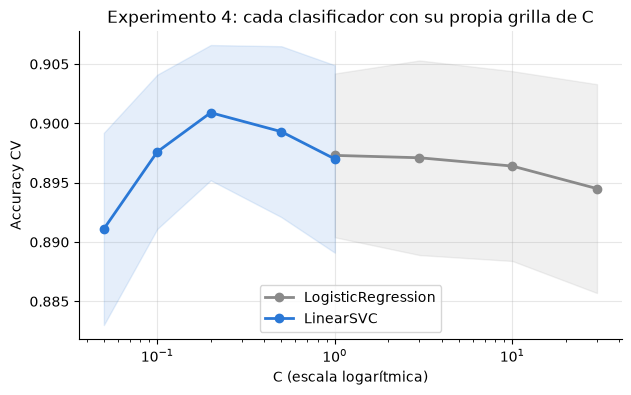

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for nombre, color in [("LogisticRegression", "#8a8a8a"), ("LinearSVC", "#2a78d6")]:
    t = tabla_e4[tabla_e4["clasificador"] == nombre].sort_values("C")
    ax.plot(t["C"], t["acc_cv"], marker="o", color=color, linewidth=2, label=nombre)
    ax.fill_between(t["C"], t["acc_cv"] - t["std_cv"], t["acc_cv"] + t["std_cv"], color=color, alpha=0.12)
ax.set_xscale("log")
ax.set_xlabel("C (escala logarítmica)")
ax.set_ylabel("Accuracy CV")
ax.set_title("Experimento 4: cada clasificador con su propia grilla de C")
ax.legend()
plt.show()

**Lectura**

- Con su propia grilla, el mejor `C` de la regresión logística es **1** (0,8973), no 10 como en los experimentos 1
  y 2: con más partes y más features conviene más regularización.
- **LinearSVC con `C = 0,2` obtiene la mejor accuracy de CV (0,9009)** y la menor desviación entre folds (0,0057).
- La ventaja sobre la mejor regresión logística es pequeña (0,0036) y menor que la desviación entre folds, así que
  ambos clasificadores rinden prácticamente igual. Se queda LinearSVC por tener la mejor accuracy media y la menor
  variación, pero la conclusión es que **la mejora del experimento 4 viene de la representación (detector de
  opinión), no del cambio de clasificador**.

Test -> accuracy: 0.8975 | F1 macro: 0.9021

              precision    recall  f1-score   support

    negativo      0.857     0.858     0.857       843
     neutral      0.988     1.000     0.994       715
    positivo      0.861     0.850     0.855       842

    accuracy                          0.897      2400
   macro avg      0.902     0.903     0.902      2400
weighted avg      0.897     0.897     0.897      2400



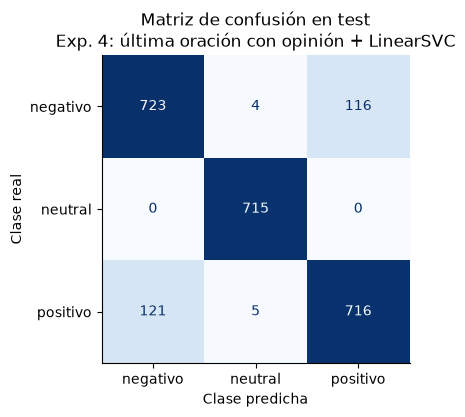

Negativo vs positivo en test: 0.854 (exp. 2: 0,859)
  reseñas que terminan en evasiva: 0.474  (n = 285)
  reseñas sin evasiva final:       0.931  (n = 1400)


In [15]:
metricas_e4 = evaluar_en_test(busqueda_e4.best_estimator_, "Exp. 4: última oración con opinión + LinearSVC")

np_test = (y_test != "neutral").to_numpy()
termina_ev_test = X_test.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()
pred = metricas_e4["pred"]
y_t = y_test.to_numpy()
print(f"Negativo vs positivo en test: {(pred[np_test] == y_t[np_test]).mean():.3f} (exp. 2: 0,859)")
print(f"  reseñas que terminan en evasiva: {(pred[np_test & termina_ev_test] == y_t[np_test & termina_ev_test]).mean():.3f}"
      f"  (n = {(np_test & termina_ev_test).sum()})")
print(f"  reseñas sin evasiva final:       {(pred[np_test & ~termina_ev_test] == y_t[np_test & ~termina_ev_test]).mean():.3f}"
      f"  (n = {(np_test & ~termina_ev_test).sum()})")

In [16]:
top_coeficientes(busqueda_e4.best_estimator_)

,negativo,neutral,positivo
0,ultima_op__mal (1.46),texto__viene (0.53),tras_sin_ev__resistente (1.19)
1,tras_sin_ev__mal (1.30),ultima_op__todavia (0.53),ultima_op__sobresaliente (1.17)
2,tras_sin_ev__pobre (1.25),texto__trae (0.51),ultima_op__confiable (1.13)
3,ultima_op__inconsistente (1.23),texto__paquete (0.51),ultima_op__decente (1.11)
4,ultima_op__poco fiable (1.22),texto__el paquete (0.50),ultima_op__eficiente (1.11)
5,tras_sin_ev__torpe (1.18),texto__unidades (0.48),ultima_op__espectacular (1.10)
6,tras_sin_ev__poco fiable (1.17),texto__la caja (0.47),tras_sin_ev__formidable (1.09)
7,ultima_op__terrible (1.16),ultima_op__lo (0.46),ultima_op__impecable (1.09)
8,ultima_op__pobre (1.15),texto__kilo (0.45),tras_sin_ev__sobresaliente (1.07)
9,tras_sin_ev__desagradable (1.13),ultima_op__las (0.43),tras_sin_ev__impecable (1.07)


### 2.6 Prueba de robustez en test

Los mismos escenarios de los experimentos 2 y 3. El experimento 4 sigue usando la posición (la **última** oración con
opinión), así que se espera que sea frágil, como el experimento 2.

In [17]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 4 (última con opinión + SVC)", "escenario": e,
          "accuracy": accuracy_score(y_test, busqueda_e4.best_estimator_.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 2 (final de la reseña),Exp. 3 (veredicto por contenido),Exp. 4 (última con opinión + SVC)
escenario,,,
Original,0.8992,0.7962,0.8975
Oraciones desordenadas,0.6858,0.8004,0.7358
Última oración al inicio,0.5742,0.7996,0.5946


### 2.7 Errores que quedan (sobre train, con predicciones de CV)

In [18]:
pred_cv_e4 = cross_val_predict(clone(busqueda_e4.best_estimator_), X_train, y_train, cv=skf, n_jobs=-1)

for nombre, m in [("negativo/positivo con evasiva final", mascara_np & termina_evasiva),
                  ("negativo/positivo sin evasiva final", mascara_np & ~termina_evasiva),
                  ("neutral", ~mascara_np)]:
    print(f"{nombre:38} exp. 2: {(pred_cv_e2[m] == y_np[m]).mean():.3f}  ->  exp. 4: {(pred_cv_e4[m] == y_np[m]).mean():.3f}"
          f"  (n = {m.sum()})")
print(f"\nReseñas negativo/positivo predichas como neutral: exp. 2: {((pred_cv_e2 == 'neutral') & mascara_np).sum()}"
      f"  ->  exp. 4: {((pred_cv_e4 == 'neutral') & mascara_np).sum()}")

errores = (pred_cv_e4 != y_np) & mascara_np & ~termina_evasiva
print()
for idx, texto in X_train[errores].sample(4, random_state=SEED).items():
    print(f"[real: {y_train[idx]}  ->  predicho: {pred_cv_e4[X_train.index.get_loc(idx)]}]")
    for oracion in dividir_oraciones(texto):
        print("    ", oracion)
    print()

negativo/positivo con evasiva final    exp. 2: 0.507  ->  exp. 4: 0.505  (n = 1078)
negativo/positivo sin evasiva final    exp. 2: 0.904  ->  exp. 4: 0.927  (n = 5661)
neutral                                exp. 2: 0.995  ->  exp. 4: 0.999  (n = 2861)

Reseñas negativo/positivo predichas como neutral: exp. 2: 84  ->  exp. 4: 29

[real: negativo  ->  predicho: positivo]
     lo pedi hace un par de semanas y llego en unos cinco dias, asi que desde entonces lo estoy probando a fondo en la sala.
     siento que tire el dinero con el sistema de sonido.
     de paso, la resolucion fue todo un acierto.
     no se, lo dejo a tu criterio.

[real: negativo  ->  predicho: positivo]
     me llego el producto el jueves a casa, lo pedi el lunes por internet.
     la ergonomia me hizo la vida mas facil.
     la uso en la oficina casi todos los dias desde que me llego.
     de paso, quede muy molesto con la aplicacion.
     la instale esa misma semana en el celular.

[real: positivo  ->  predicho: neg

### 2.8 Registro y envío

In [19]:
registrar_resultado(
    experimento=4,
    descripcion="Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC",
    busqueda=busqueda_e4,
    metricas_test=metricas_e4,
    envio="submission_04.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,NaN
3,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': LinearSVC(max_iter=5000, random_state=42), 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN


In [20]:
envio_e4 = generar_envio(busqueda_e4, numero=4)

Envío guardado en envios/submission_04.csv y modelo en modelos/modelo_04.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.3
neutral     27.7
positivo    37.0


### 2.9 Análisis del experimento 4

**Resultados:** accuracy de CV = **0,9009 ± 0,0057** (LinearSVC, `C = 0,2`, elegido entre regresión logística y
LinearSVC con sus propias grillas) frente a 0,8865 del experimento 2; accuracy en test = **0,8975** frente a 0,8992.
La mejor regresión logística con esta misma representación obtiene 0,8973 en CV, prácticamente igual: la mejora
viene del detector de opinión, no del clasificador.

| | Exp. 2 | Exp. 4 |
|---|---|---|
| Accuracy CV | 0,8865 ± 0,0099 | **0,9009 ± 0,0057** |
| Folds en que gana | — | **5 de 5** |
| CV, negativo/positivo sin evasiva final | 0,904 | **0,927** |
| CV, negativo/positivo con evasiva final | 0,507 | 0,505 |
| Negativo/positivo predichas como `neutral` (CV) | 84 | **29** |
| Accuracy test | 0,8992 | 0,8975 |
| Test, oraciones desordenadas | 0,686 | 0,736 |
| Test, última oración al inicio | 0,574 | 0,595 |

1. **La mejora en CV es consistente:** +1,4 puntos y gana en los 5 folds. Viene de las reseñas **sin** evasiva final
   (0,904 → 0,927): el detector salta oraciones finales descriptivas y el modelo deja de confundir reseñas con
   opinión con `neutral` (84 → 29).
2. **En el test la diferencia no se confirma** (0,8975 frente a 0,8992, unas 4 reseñas de 2.400). Con 2.400 reseñas,
   el error estándar de la accuracy es ≈ 0,006, así que ambas cifras son compatibles. Además, el test tiene un 17 %
   de reseñas `negativo`/`positivo` que terminan en evasiva (285), donde cualquier modelo acierta ≈ 50 % al azar, lo
   que añade ruido a la comparación. Siguiendo la regla del proyecto, **se decide con la CV** (más datos, 5
   particiones) y el test solo se reporta.
3. **Hay un techo de ruido irreducible:** ≈ 16 % de las reseñas `negativo`/`positivo` terminan en una evasiva y su
   etiqueta no se puede predecir mejor que el azar (sección 2.2). Esto limita la accuracy máxima alcanzable a ≈ 0,94 y
   hace que los scores del leaderboard público tengan bastante variación: una diferencia de 0,88 a 0,90 entre equipos
   puede deberse en parte a ese ruido.
4. **Sigue dependiendo de la posición:** la prueba de robustez da 0,736 con las oraciones desordenadas y 0,595 con la
   última oración al inicio (algo mejor que el experimento 2, pero igual de frágil). Las conclusiones de los
   experimentos 2 y 3 sobre el compromiso entre accuracy y robustez se mantienen.
5. **Los coeficientes** siguen concentrados en las partes finales (`ultima_op__mal`, `tras_sin_ev__pobre`,
   `ultima_op__sobresaliente`), y `neutral` en el vocabulario descriptivo del texto completo.

**Errores que quedan** (sección 2.7): oraciones finales con opinión que el modelo no reconoce como tal, opiniones
introducidas por `de paso` o `por otro lado` que no deciden el veredicto, y reseñas que terminan con una oración
descriptiva que el detector no salta.

**Decisión:** el experimento 4 pasa a ser el **mejor modelo según la CV** y se envía como `submission_04.csv`. El
score público ayudará a confirmar si la mejora se traslada; si no, la diferencia probablemente esté dentro del ruido.

**Próximos pasos posibles:** ajustar la representación de las partes (`min_df`, n-gramas) con LinearSVC, comparar
con Naive Bayes, y mejorar el detector de opinión (más ejemplos de oraciones con opinión, umbral).